In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [2]:
### **Hypothesis 1 : There is more incidents with T1 vehicles than with T2 vehicles (> 50% of the incidents are with T1 vehicles)**

#### Justification :
# This hypothesis is linked to the problem because, if the tier of a vehicule influence the probability of having an accident, then this is an important information for our IA model

#### H0 and Ha :
##### H0 :
# The percentage of T1 incidents is equal to or less than 50% of the total incidents.
##### Ha :
# The percentage of T1 incidents is greater than 50% of the total incidents.

#### if X then Y format :
# If the bar representing T1 vehicles is higher than the bar representing T2 vehicles, then there is more incidents with T1 vehicles than with T2 vehicles

#### Text describing the hypothesis :
# The hypothesis is that there are more incidents with T1 vehicles than with T2 vehicles. This means that if the number of incidents for T1 vehicles is significantly higher than the number of incidents for T2 vehicles, then the hypothesis is supported. The analysis will involve counting the number of incidents for each tier category and comparing them. If T1 vehicles have significantly more incidents than T2 vehicles, then the hypothesis is supported.

#### Result :
# 62.35% of the incidents happened with a T1 vehicule, and 37.65% with a T2 vehicule.

#### Probability of the result happening by chance :
# We will be using the z-test to determine the probability of the result happening by chance.
# 𝜎 = sqrt(n * p * (1 - p)) = sqrt(357,989 * 0.5 * 0.5) ≈ 298.3
# z = 223,036 − 178,994.5 / 298.3 ≈ 44,041.5 / 298.3 ≈ 147.6
# The z-score is extremely high, so the probability of the result happening by chance is extremely low, so there is a real correlation between the tier categorie and the number of incidents.

#### Result for H0 and Ha :
# We reject the null hypothesis (H0) and accept the alternative hypothesis (Ha). The data shows that 62.35% of the incidents are associated with T1 vehicles, which is significantly greater than 50%. This indicates that there are indeed more incidents with T1 vehicles compared to T2 vehicles.

#### Include the analysis as evidence :

def hypothesis1():
    print(
        "HYPOTHESIS 1 : There is more incidents with T1 vehicles than with T2 vehicles (> 50% of the incidents are with T1 vehicles)")
    df = pd.read_excel("data/SERVICE_ORDER_BASE.xlsx", usecols=['TIER'], engine='openpyxl')
    print(df.head())

    # Create a new dataframe
    df_model = df[['TIER']].copy()

    # Count the number of time each TIER appears, for each TIER
    df_model_count = df_model.groupby('TIER').size().reset_index(name='count')

    # Create a column containing each unique TIER
    df_model_count['TIER'] = df_model_count['TIER']

    # Divide the number of T1 and T2 vehicules by the number of unique vehicules with T1 or T2 Tier, using a cleaned version of SERVICE_ORDER_BASE.xlsx, which exclude every duplicate ASSET CODE
    df_service = pd.read_excel("data/SERVICE_ORDER_BASE.xlsx", engine='openpyxl')
    df_service = df_service.drop_duplicates(subset=['ASSET CODE'])
    df_service = df_service[df_service['MANUFACTURE YEAR'] >= 2015]
    df_service_count = df_service.groupby('TIER').size().reset_index(name='vehicule_count')
    df_model_count = pd.merge(df_model_count, df_service_count, on='TIER', how='left')
    df_model_count['count'] = df_model_count['count'] / df_model_count['vehicule_count']
    df_model_count = df_model_count.drop(columns=['vehicule_count'])

    # Create a column containing the number of times each TIER appears
    df_model_count['percentage'] = (df_model_count['count'] / df_model_count['count'].sum()) * 100

    # Sort the dataframe by count in descending order
    df_model_count = df_model_count.sort_values(by='percentage', ascending=False)
    print(df_model_count)

    # Create a histogram plot representing the number of incidents, per TIER
    plt.figure(figsize=(8, 6))
    sns.barplot(x='TIER', y='percentage', data=df_model_count, hue='percentage', palette='icefire')
    plt.title('Percentage of Incidents per Tier')
    plt.xlabel('Tier')
    plt.ylabel('Percentage of Incidents')
    plt.tight_layout()

    # Save the plot as a PNG file
    plt.savefig('hypothesis1.png', dpi=300)

    plt.show()

In [3]:
### **Hypothesis 2 : Older vehicles have more incidents**

#### Justification :
# This hypothesis is linked to the problem because, if older vehicules have a higher probability of having an accident, then this is an important information for our IA model

#### H0 and Ha :
##### H0 :
# There is no correlation between the date of purchase and the probability of having an incident.
##### Ha :
# There is a correlation between the date of purchase and the probability of having an incident.

#### if X then Y format :
# If the bar representing older vehicles is higher than others, then the date of purchase (i.e the age of the vehicule) correlate with the probability of having an incident

#### Text describing the hypothesis :
# The hypothesis is that the date of purchase correlate with the probability of having an incident. This means that if a vehicle is older, it is more likely to have more incidents. This could be due to the fact that older vehicles are more likely to have wear and tear, or because they may not have the latest safety features. The analysis will involve counting the number of incidents for each purchase year and comparing them. If older vehicles have significantly more incidents than newer vehicles, then the hypothesis is supported.

#### Result :
# The number of incidents decrease as year increase, showing that older vehicles have more incidents.

#### Probability of the result happening by chance :
# We will be using the chi-squared test to determine the probability of the result happening by chance.
# Total = 1,178.76
# Expected = 1178.76 / 10 = 117.88
# χ² = Σ((O - E)² / E) ≈ 421.41
# Degrees of freedom = number of categories − 1 = 10 − 1 = 9
# Critical value at α = 0.05 for 9 degrees of freedom = 16.92
# A chi-square value of 421.41 (>>16.92) with 9 degrees of freedom is astronomically unlikely under the null hypothesis (fair dice).

#### Result for H0 and Ha :
# We reject the null hypothesis (H0) and accept the alternative hypothesis (Ha). The data shows a clear correlation between the date of purchase and the probability of having an incident. Older vehicles tend to have more incidents compared to newer vehicles, indicating that the date of purchase does indeed influence the likelihood of incidents.

#### Include the analysis as evidence :

def hypothesis2():
    print(
        "HYPOTHESIS 2 : The date of purchase correlate with the probability of having an incident (older vehicles have more incidents)")
    # Charger seulement la colonne qui existe réellement dans le fichier
    df = pd.read_excel("data/SERVICE_ORDER_BASE.xlsx", usecols=['ASSET PURCHASE DATE'], engine='openpyxl')
    print(df.head())

    # Convert the 'ASSET PURCHASE DATE' column to datetime format
    df['ASSET PURCHASE DATE'] = pd.to_datetime(df['ASSET PURCHASE DATE'], errors='coerce')
    print(df['ASSET PURCHASE DATE'].head())
    print(df['ASSET PURCHASE DATE'].dtype)
    print(df['ASSET PURCHASE DATE'].isnull().sum())
    df = df.dropna(subset=['ASSET PURCHASE DATE'])
    print(df['ASSET PURCHASE DATE'].isnull().sum())

    # Extract the year from the 'ASSET PURCHASE DATE' column
    df['PURCHASE_YEAR'] = df['ASSET PURCHASE DATE'].dt.year
    print(df['PURCHASE_YEAR'].head())
    print(df['PURCHASE_YEAR'].dtype)

    # Create a new dataframe
    df_model = df[['PURCHASE_YEAR']].copy()

    # Remove every year before 2014, and remove 2025
    df_model = df_model[(df_model['PURCHASE_YEAR'] >= 2015) & (df_model['PURCHASE_YEAR'] <= 2024)]

    # Count the number of time each PURCHASE_YEAR appears
    df_model_count = df_model.groupby('PURCHASE_YEAR').size().reset_index(name='count')

    # Divide this number by the number of unique vehicules in the year, using a cleaned version of SERVICE_ORDER_BASE.xlsx, which exclude every duplicate ASSET CODE
    df_service = pd.read_excel("data/SERVICE_ORDER_BASE.xlsx", engine='openpyxl')
    df_service = df_service.drop_duplicates(subset=['ASSET CODE'])
    df_service = df_service[df_service['MANUFACTURE YEAR'] >= 2015]
    df_service = df_service.dropna(subset=['ASSET PURCHASE DATE'])
    df_service['ASSET PURCHASE DATE'] = pd.to_datetime(df_service['ASSET PURCHASE DATE'], errors='coerce')
    df_service = df_service.dropna(subset=['ASSET PURCHASE DATE'])
    df_service['PURCHASE_YEAR'] = df_service['ASSET PURCHASE DATE'].dt.year
    df_service = df_service[(df_service['PURCHASE_YEAR'] >= 2015) & (df_service['PURCHASE_YEAR'] <= 2024)]
    df_vehicule_count = df_service.groupby('PURCHASE_YEAR').size().reset_index(name='vehicule_count')
    df_model_count = pd.merge(df_model_count, df_vehicule_count, on='PURCHASE_YEAR', how='left')
    df_model_count['count'] = df_model_count['count'] / df_model_count['vehicule_count']
    df_model_count = df_model_count.drop(columns=['vehicule_count'])

    # Create a column containing the percentage
    df_model_count['percentage'] = (df_model_count['count'] / df_model_count['count'].sum()) * 100

    # Sort the dataframe by PURCHASE_YEAR in ascending order
    df_model_count = df_model_count.sort_values(by='percentage', ascending=True)
    print(df_model_count)

    # Create a histogram plot representing the percentage of incidents per PURCHASE_YEAR
    plt.figure(figsize=(12, 6))
    sns.barplot(x='PURCHASE_YEAR', y='percentage', data=df_model_count, hue='percentage', palette='flare', legend=False)
    plt.title('Percentage of Incidents per Purchase Year')
    plt.xlabel('Purchase Year')
    plt.ylabel('Percentage of Incidents')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Save the plot as a PNG file
    plt.savefig('hypothesis2.png', dpi=300)

    plt.show()

In [4]:
### **Hypothesis 3 : There is a correlation between the mileage and the probability of having an incident**

#### Justification :
# This hypothesis is linked to the problem because, if vehicules with higher milage (kilometragem) have a higher probability of having an accident, then this is an important information for our IA model

#### H0 and Ha :
##### H0 :
# There is no correlation between the number of kilometers and the number of incidents.
##### Ha :
# There is a correlation between the number of kilometers and the number of incidents.

#### if X then Y format :
# If the bar representing the vehicles with more kilometers is higher than the others, then the more kilometers a vehicle has, the more incidents it has

#### Text describing the hypothesis :
#  hypothesis is that there is a correlation between the number of kilometers and the number of incidents. This means that if a vehicle has more kilometers, it is more likely to have more incidents. This could be due to the fact that vehicles with higher mileage may experience more wear and tear, leading to a higher likelihood of incidents. The analysis will involve counting the number of incidents for vehicles with different kilometer ranges and comparing them. If vehicles with higher kilometers have significantly more incidents than those with lower kilometers, then the hypothesis is supported.

#### Result :
# The milage seems to influence the probability of having an incident, as more incidents happens over the increasing of the kilometrage.

#### Result for H0 and Ha :
# We reject the null hypothesis (H0) and accept the alternative hypothesis (Ha). The data does show a clear correlation between the number of kilometers and the number of incidents. The distribution of incidents across different kilometer ranges indicate that vehicles with higher mileage have significantly more incidents than those with lower mileage.

#### Include the analysis as evidence :

def hypothesis3():
    print(
        "HYPOTHESIS 3 : There is a correlation between the number of kilometers and the number of incidents (more kilometers = more incidents)")

    # Load data
    df = pd.read_excel("data/SERVICE_ORDER_BASE.xlsx", usecols=['COUNTER  OF SERVICE ORDER'], engine='openpyxl')

    # Drop invalids
    df = df.dropna(subset=['COUNTER  OF SERVICE ORDER'])

    # Remove values below 0
    df = df[df['COUNTER  OF SERVICE ORDER'] > 0]

    # Bin kilometers into ranges of 10,000 km
    bins = list(range(0, 300001, 10000))
    labels = [f"{b}-{b + 10000}" for b in bins[:-1]]
    df['KM_RANGE'] = pd.cut(df['COUNTER  OF SERVICE ORDER'], bins=bins, labels=labels, right=False)

    # Count incidents per kilometer range
    df_model_count = (
        df.groupby('KM_RANGE')
        .size()
        .reset_index(name='count')
        .sort_values(by='KM_RANGE')
    )

    # Divide this number by the number of unique vehicules for every range, using a cleaned version of SERVICE_ORDER_BASE.xlsx, which exclude every duplicate ASSET CODE
    # Create the dataframes
    df_service = pd.read_excel("data/SERVICE_ORDER_BASE.xlsx", engine='openpyxl')

    # Clean the data
    df_service = df_service.drop_duplicates(subset=['ASSET CODE'])
    df_service = df_service[df_service['MANUFACTURE YEAR'] >= 2015]

    # Divide
    df_service = df_service.dropna(subset=['COUNTER  OF SERVICE ORDER'])
    df_service = df_service[df_service['COUNTER  OF SERVICE ORDER'] > 0]
    df_service['KM_RANGE'] = pd.cut(df_service['COUNTER  OF SERVICE ORDER'], bins=bins, labels=labels, right=False)
    df_service_count = df_service.groupby('KM_RANGE').size().reset_index(name='vehicule_count')
    df_model_count = pd.merge(df_model_count, df_service_count, on='KM_RANGE', how='left')
    df_model_count['count'] = df_model_count['count'] / df_model_count['vehicule_count']
    df_model_count = df_model_count.drop(columns=['vehicule_count'])

    # Create a column containing the percentage
    df_model_count['percentage'] = (df_model_count['count'] / df_model_count['count'].sum()) * 100

    # Sort the dataframe by PURCHASE_YEAR in ascending order
    df_model_count = df_model_count.sort_values(by='percentage', ascending=True)
    print(df_model_count)

    # Plot
    plt.figure(figsize=(12, 6))
    sns.barplot(x='KM_RANGE', y='percentage', data=df_model_count,
                hue='percentage', palette='crest', legend=False)
    plt.title('Percentage of Incidents per Kilometer Range')
    plt.xlabel('Kilometer Range')
    plt.ylabel('Percentage of Incidents')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Save the plot as a PNG file
    plt.savefig('hypothesis3.png', dpi=300)

    plt.show()

In [5]:
## **Possible bias for all hypotheses :**
# The dataset used is a cleaned version of the SERVICE_ORDER_BASE dataset, which only includes vehicules that were involved at least once in an incident, without duplicates.
# Therefore, this data does not include vehicules that were never involved in an incident, which are as important for the analysis.

# Our calculations concluded that there is 2803 unique vehicles in SERVICE_ORDER_BASE, and 3556 vehicles in VEHICLES_BASE, which directly indiquates that 753 vehicles are missing in the SERVICE_ORDER_BASE.
# In the VEHICLES_BASE database, there is not every variable and information that are in the SERVICE_ORDER_BASE database, so we decided to use a cleaned version of SERVICE_ORDER_BASE, and, therefore, ignoring every vehicule that never had an incident, rather than using the VEHICLES_BASE database, that does not contains critical datas.

HYPOTHESIS 1 : There is more incidents with T1 vehicles than with T2 vehicles (> 50% of the incidents are with T1 vehicles)
          TIER
0  TIER 1 - T1
1  TIER 2 - T2
2  TIER 2 - T2
3  TIER 2 - T2
4  TIER 1 - T1
          TIER       count  percentage
0  TIER 1 - T1  186.030769   62.349718
1  TIER 2 - T2  112.335888   37.650282


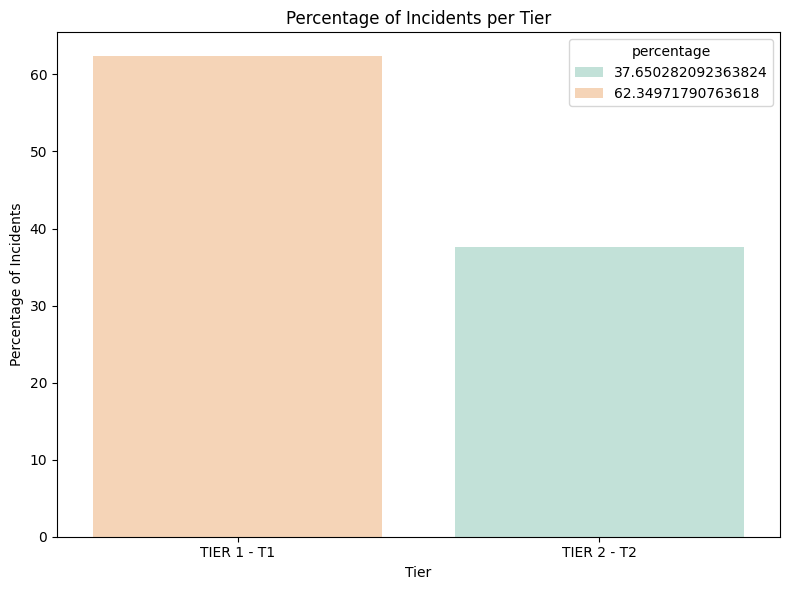

HYPOTHESIS 2 : The date of purchase correlate with the probability of having an incident (older vehicles have more incidents)
   ASSET PURCHASE DATE
0  2017-09-22 00:00:00
1  2017-10-24 00:00:00
2  2019-08-29 00:00:00
3  2014-11-01 00:00:00
4  2015-09-28 00:00:00
0   2017-09-22
1   2017-10-24
2   2019-08-29
3   2014-11-01
4   2015-09-28
Name: ASSET PURCHASE DATE, dtype: datetime64[ns]
datetime64[ns]
0
0
0    2017
1    2017
2    2019
3    2014
4    2015
Name: PURCHASE_YEAR, dtype: int32
int32
   PURCHASE_YEAR       count  percentage
9           2024   11.211765    0.951960
8           2023   39.491525    3.353116
7           2022   48.386301    4.108346
6           2021   83.052632    7.051768
5           2020   85.665761    7.273641
3           2018  133.066351   11.298294
4           2019  161.556777   13.717336
0           2015  182.696884   15.512284
2           2017  207.100917   17.584363
1           2016  225.527273   19.148893


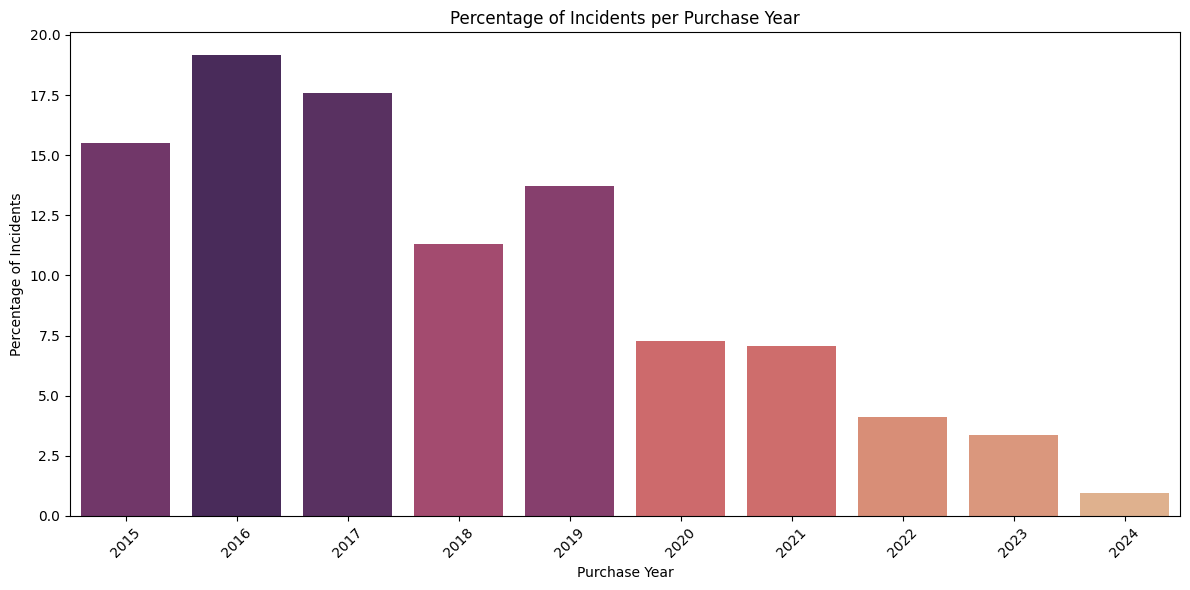

HYPOTHESIS 3 : There is a correlation between the number of kilometers and the number of incidents (more kilometers = more incidents)


C:\Users\Inteli\AppData\Local\Temp\ipykernel_5304\1228861847.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('KM_RANGE')
C:\Users\Inteli\AppData\Local\Temp\ipykernel_5304\1228861847.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_service_count = df_service.groupby('KM_RANGE').size().reset_index(name='vehicule_count')


         KM_RANGE       count  percentage
0         0-10000   10.785124    0.141959
1     10000-20000   19.208092    0.252826
2     20000-30000   32.678445    0.430129
3     30000-40000   48.309392    0.635870
4     40000-50000   86.437500    1.137730
5     50000-60000   94.539062    1.244367
6     60000-70000  121.473214    1.598886
7     70000-80000  122.794118    1.616273
8     80000-90000  145.010309    1.908693
9    90000-100000  170.524390    2.244521
27  270000-280000  176.125000    2.318238
15  150000-160000  216.390244    2.848228
11  110000-120000  223.444444    2.941079
28  280000-290000  229.454545    3.020186
10  100000-110000  253.186441    3.332557
13  130000-140000  254.878049    3.354822
24  240000-250000  257.615385    3.390852
14  140000-150000  259.450000    3.415000
17  170000-180000  277.740741    3.655752
12  120000-130000  317.560976    4.179884
29  290000-300000  334.375000    4.401198
20  200000-210000  337.846154    4.446887
18  180000-190000  355.588235    4

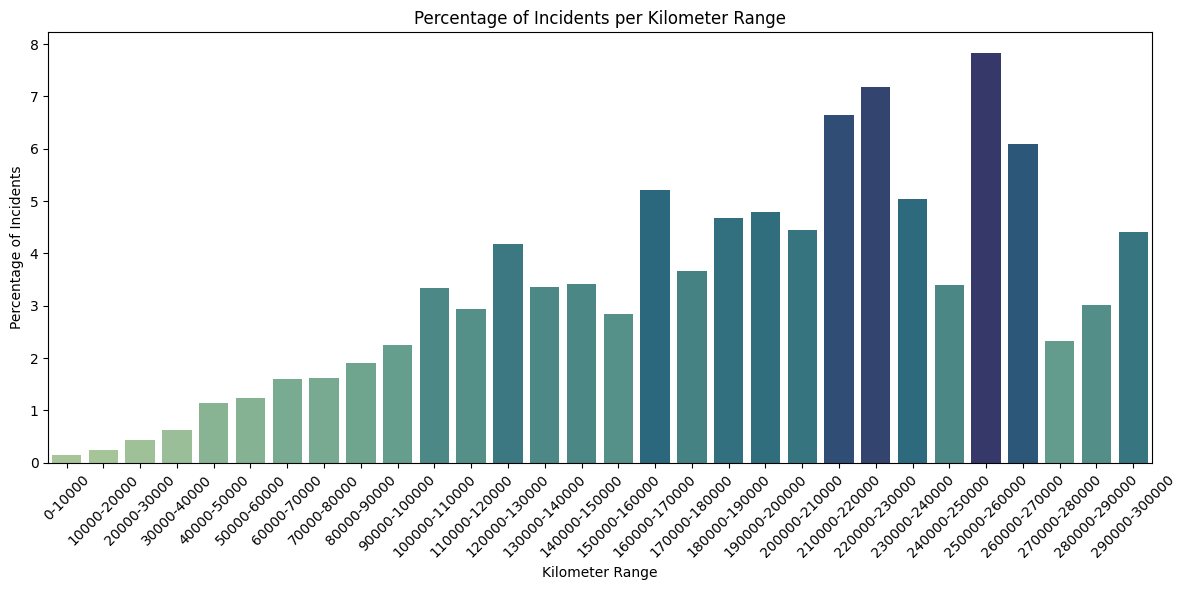

In [6]:
hypothesis_to_run = [0]

if 1 in hypothesis_to_run:
    hypothesis1()
if 2 in hypothesis_to_run:
    hypothesis2()
if 3 in hypothesis_to_run:
    hypothesis3()
if 0 in hypothesis_to_run:
    hypothesis1()
    hypothesis2()
    hypothesis3()